# COMP5339 Data Engineering — Assignment 2 (Group 156)
**Group 156** — Member 1 (540989498) · Member 2 (540929966) · Member 3 (540903678)


## Tasks 1–3: Data Retrieval, Integration & Materialisation, MQTT Publishing

This notebook implements the first three tasks of Assignment 2:

1. **Data Retrieval** — Pull per-facility power generation and CO2 emissions from the
   OpenElectricity REST API for the NEM network at the 5-minute interval, for one
   week of May 2026. Optionally also pull per-market price and demand.
2. **Data Integration & Materialisation/Caching** — Combine power and emissions into
   a single consolidated facility dataset, clean it, and persist it to CSV so the rest
   of the pipeline does not have to touch the API again.
3. **Data Publishing via MQTT** — Stream the consolidated records to a public MQTT
   broker in chronological event order with a 0.1 s delay between messages.

This notebook is the **publisher** half of the system and actually covers **Tasks 1, 2, 3, 4 and 6** (data retrieval, integration/caching, MQTT publishing, the Assignment 1 DuckDB schema, and continuous execution). **Only Task 5** — the subscriber and live map dashboard — lives in the separate notebook `Assignment2_Dashboard_Group156.ipynb`.

## How to run

1. **Install dependencies:** run `pip install -r requirements.txt` in the folder that contains `requirements.txt`. (You can just remove the comment of the first code cell and run it)
2. **Launch Jupyter and open this notebook.** Run **Tasks 1-4** top to bottom; this builds `data/consolidated_facility_5min.csv` and `data/electricity_a2.duckdb`. Stop before Task 6.
3. **Open `Assignment2_Dashboard_Group156.ipynb` and Run All** (Task 5). The dashboard opens at http://127.0.0.1:8050 and waits for data.
4. **Return here and run Task 6** (`run_continuous_stream`) to start the live stream; set `rounds=None` for an unbounded stream. The markers then populate the dashboard live.

> Run the two notebooks in **separate kernels**; they communicate only through the MQTT broker.

In [4]:
#%pip install -r requirements.txt

In [5]:
import os
import json
import time
import logging
import threading
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import requests
import paho.mqtt.client as mqtt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

In [6]:
# --- OpenElectricity API key -------------------------------------------------
# As instructed, the API key is included directly in the code below. Paste your
# own OpenElectricity key in place of the placeholder before running. (If the
# environment variable OPENELECTRICITY_API_KEY is set it takes precedence, so
# the notebook also runs on a shared machine without editing this cell.)
# NOTE: every raw API response is cached under data/raw_openelectricity/, so the
# whole pipeline re-runs end-to-end from that cache even without a valid key.
API_KEY = os.environ.get(
    "OPENELECTRICITY_API_KEY", "REPLACE_ME",
)
API_BASE = "https://api.openelectricity.org.au/v4"

NETWORK_CODE = "NEM"      # NEM covers QLD, NSW, VIC, SA, TAS
INTERVAL = "5m"           # 5-minute interval per the assignment brief

# One week of 5-minute data in May 2026. The API caps a single 5m-interval
# request at an 8-day window, so our 7-day window (2026-05-12 -> 2026-05-19)
# fits comfortably in one pass per batch.
DATE_END = datetime(2026, 5, 19, 0, 0, tzinfo=timezone.utc)
DATE_START = DATE_END - timedelta(days=7)

DATA_DIR = Path("data")
RAW_CACHE_DIR = DATA_DIR / "raw_openelectricity"
CONSOLIDATED_CSV = DATA_DIR / "consolidated_facility_5min.csv"
MARKET_CSV = DATA_DIR / "market_price_demand_5min.csv"
FACILITIES_JSON = RAW_CACHE_DIR / "facilities.json"
HIGHWATER_PATH = DATA_DIR / "mqtt_last_publish.json"
for d in (DATA_DIR, RAW_CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

MQTT_HOST = "broker.hivemq.com"
MQTT_PORT = 1883
MQTT_TOPIC = "comp5339/group156/electricity"
MQTT_DELAY_SEC = 0.1      # required minimum delay between published messages
MQTT_QOS = 0
MQTT_CLIENT_ID = f"comp5339-group156-{int(time.time())}"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(name)s | %(message)s",
)
log = logging.getLogger("a2")
log.info(f"Window: {DATE_START.date()} -> {DATE_END.date()} "
         f"(interval={INTERVAL}, network={NETWORK_CODE})")

2026-05-30 00:00:31,703 INFO a2 | Window: 2026-05-12 -> 2026-05-19 (interval=5m, network=NEM)


## Task 1 — Data Retrieval

The OpenElectricity v4 REST API exposes two relevant endpoints:

- `GET /v4/facilities/` — list all facilities in a network with their unit metadata.
- `GET /v4/data/facilities/{network_code}` — facility-level time-series. Accepts a
  list of `facility_code` values (capped at **fewer than 30 per request**) and a list
  of `metrics`, so we can pull `power` + `emissions` for a batch of facilities at once.

That bulk-fetch capability is the key to staying under the 500/day budget. With
BATCH_SIZE = 25 we make **~18 data requests + 1 facility-list + 1 market = 20 total** —
nowhere near the cap.

Every raw response is written to disk as JSON. Re-running the notebook after a
cache exists is a no-op — exactly the materialisation pattern Task 2 asks for, and
it also means Task 3 never has to touch the network again.

In [7]:
class OpenElectricityClient:
    """Thin wrapper around the OpenElectricity v4 REST API.

    Handles bearer auth, ISO-8601 date formatting, retries on 429/5xx only
    (never on 4xx — those are permanent), and a small request counter so we
    can see how much of the 500/day budget we used.
    """

    def __init__(self, api_key: str, base_url: str = API_BASE):
        if not api_key or "REPLACE_ME" in api_key:
            log.warning("No API key set — live calls will 401. "
                        "Set OPENELECTRICITY_API_KEY to fetch new data.")
        self.session = requests.Session()
        self.session.headers.update({
            "Authorization": f"Bearer {api_key}",
            "Accept": "application/json",
            "User-Agent": "COMP5339-Group156-A2/1.0",
        })
        self.base = base_url.rstrip("/")
        self.requests_made = 0

    @staticmethod
    def _fmt(d: datetime) -> str:
        # API expects ISO-8601 without microseconds. We normalise to UTC.
        if d.tzinfo is None:
            d = d.replace(tzinfo=timezone.utc)
        return d.astimezone(timezone.utc).strftime("%Y-%m-%dT%H:%M:%S")

    def _get(self, path, params=None):
        """GET with retry on 429/5xx only. Raises immediately on 4xx."""
        url = f"{self.base}/{path.lstrip('/')}"
        last_err = None
        for attempt in range(4):
            try:
                r = self.session.get(url, params=params, timeout=120)
            except requests.RequestException as e:
                # Connection error / timeout — worth a retry.
                last_err = str(e)
                time.sleep(2 * (attempt + 1))
                continue
            self.requests_made += 1
            if r.status_code == 429:
                wait = int(r.headers.get("Retry-After", "30"))
                log.warning(f"429 rate-limited on {path}, sleeping {wait}s")
                time.sleep(wait)
                continue
            if 500 <= r.status_code < 600:
                last_err = f"HTTP {r.status_code}"
                time.sleep(2 * (attempt + 1))
                continue
            if 400 <= r.status_code < 500:
                raise requests.HTTPError(
                    f"{r.status_code} on {url}: {r.text[:300]}", response=r,
                )
            return r.json()
        raise RuntimeError(f"Failed {url} after retries: {last_err}")

    def list_facilities(self, network_id: str = "NEM") -> dict:
        # Single request -> every facility + unit metadata for the network.
        return self._get("facilities/", params={"network_id": network_id})

    def facilities_timeseries(self, network_code, facility_codes,
                              metrics, interval, date_start, date_end):
        """Bulk per-facility time-series for the given network.

        `metrics` and `facility_codes` are repeated query params (e.g.
        `?metrics=power&metrics=emissions&facility_code=ADP&facility_code=AGLHAL`)
        — passing lists to requests does this automatically.
        """
        params = [
            ("interval", interval),
            ("date_start", self._fmt(date_start)),
            ("date_end", self._fmt(date_end)),
        ]
        for m in metrics:
            params.append(("metrics", m))
        for fc in facility_codes:
            params.append(("facility_code", fc))
        return self._get(f"data/facilities/{network_code}", params=params)

    def market_timeseries(self, network_code, metrics, interval,
                          date_start, date_end):
        params = [
            ("interval", interval),
            ("date_start", self._fmt(date_start)),
            ("date_end", self._fmt(date_end)),
        ]
        for m in metrics:
            params.append(("metrics", m))
        return self._get(f"market/network/{network_code}", params=params)


client = OpenElectricityClient(API_KEY)

In [8]:
# List of NEM Facilities
if FACILITIES_JSON.exists():
    log.info(f"Loading facility list from cache: {FACILITIES_JSON.name}")
    facilities_raw = json.loads(FACILITIES_JSON.read_text(encoding="utf-8"))
else:
    log.info("Fetching NEM facility list from API...")
    facilities_raw = client.list_facilities(network_id=NETWORK_CODE)
    FACILITIES_JSON.write_text(json.dumps(facilities_raw, indent=2),
                               encoding="utf-8")

records = []
for fac in facilities_raw.get("data", []):
    fcode = fac.get("code") or fac.get("facility_code")
    if not fcode:
        continue
    loc = fac.get("location") or {}
    base = {
        "facility_code": fcode,
        "facility_name": fac.get("name"),
        "network_id": fac.get("network_id") or NETWORK_CODE,
        "network_region": fac.get("network_region"),
        "description": fac.get("description"),
        "lat": loc.get("lat") or loc.get("latitude"),
        "lon": loc.get("lng") or loc.get("longitude") or loc.get("lon"),
    }
    units = fac.get("units") or [{}]
    for u in units:
        records.append({
            **base,
            "unit_code": u.get("code"),
            "fueltech_id": u.get("fueltech_id"),
            "status_id": u.get("status_id"),
            "capacity_registered_mw": u.get("capacity_registered"),
            "dispatch_type": u.get("dispatch_type"),
            "emissions_factor_co2": u.get("emissions_factor_co2"),
        })

facilities_df = pd.DataFrame.from_records(records)
log.info(
    f"NEM facilities: {facilities_df['facility_code'].nunique()} "
    f"({len(facilities_df)} unit rows)"
)

# 5-min power/emissions stream.
operating = facilities_df.loc[
    facilities_df["status_id"].fillna("").str.lower().isin({"operating", ""})
]
facility_codes = sorted(operating["facility_code"].dropna().unique().tolist())
log.info(f"Will request 5-min data for {len(facility_codes)} operating facilities")
facilities_df.head()

2026-05-30 00:00:31,741 INFO a2 | Loading facility list from cache: facilities.json
2026-05-30 00:00:31,761 INFO a2 | NEM facilities: 542 (958 unit rows)
2026-05-30 00:00:31,767 INFO a2 | Will request 5-min data for 432 operating facilities


,facility_code,facility_name,network_id,network_region,description,lat,lon,unit_code,fueltech_id,status_id,capacity_registered_mw,dispatch_type,emissions_factor_co2
0,ADP,Adelaide Desalination,NEM,SA1,"<p>The Adelaide Desalination plant (ADP), form...",-35.100751,138.483357,ADPBA1G,battery_discharging,operating,7.76,GENERATOR,NaN
1,ADP,Adelaide Desalination,NEM,SA1,"<p>The Adelaide Desalination plant (ADP), form...",-35.100751,138.483357,ADPBA1,battery,operating,7.76,BIDIRECTIONAL,NaN
2,ADP,Adelaide Desalination,NEM,SA1,"<p>The Adelaide Desalination plant (ADP), form...",-35.100751,138.483357,ADPPV1,solar_utility,operating,24.75,GENERATOR,NaN
3,ADP,Adelaide Desalination,NEM,SA1,"<p>The Adelaide Desalination plant (ADP), form...",-35.100751,138.483357,ADPBA1L,battery_charging,operating,7.76,LOAD,NaN
4,ADP,Adelaide Desalination,NEM,SA1,"<p>The Adelaide Desalination plant (ADP), form...",-35.100751,138.483357,ADPPV2,solar_utility,operating,0.20,GENERATOR,NaN


In [9]:
# Batched per-facility 5-min power

METRICS = ["power", "emissions"]
BATCH_SIZE = 25  


def _batches(seq, n):
    for i in range(0, len(seq), n):
        yield i // n, seq[i:i + n]


def batch_cache_path(batch_idx: int) -> Path:
    return RAW_CACHE_DIR / (
        f"batch_{batch_idx:03d}__{DATE_START:%Y%m%d}_{DATE_END:%Y%m%d}.json"
    )


DAILY_BUDGET = 480
batch_plan = list(_batches(facility_codes, BATCH_SIZE))
to_fetch = [(i, b) for (i, b) in batch_plan if not batch_cache_path(i).exists()]

log.info(
    f"Batches total: {len(batch_plan)} | cached: {len(batch_plan) - len(to_fetch)} "
    f"| to fetch this run: {len(to_fetch)} | budget headroom: {DAILY_BUDGET}"
)

for batch_idx, batch in to_fetch:
    cp = batch_cache_path(batch_idx)
    try:
        payload = client.facilities_timeseries(
            NETWORK_CODE, batch, METRICS, INTERVAL, DATE_START, DATE_END,
        )
        cp.write_text(json.dumps(payload), encoding="utf-8")
        log.info(
            f"  batch {batch_idx + 1}/{len(batch_plan)} "
            f"({len(batch)} facilities) -> {cp.name} "
            f"[{cp.stat().st_size / 1e6:.2f} MB]"
        )
    except Exception as e:
        log.error(f"  batch {batch_idx} failed: {e}")

log.info(f"Done. Requests this session: {client.requests_made}")

2026-05-30 00:00:31,803 INFO a2 | Batches total: 18 | cached: 18 | to fetch this run: 0 | budget headroom: 480
2026-05-30 00:00:31,804 INFO a2 | Done. Requests this session: 0


In [10]:
# --- 1.3 (Optional) NEM market price & demand --------------------------------
# One bulk request for the whole network — constant cost vs per-facility.

MARKET_JSON = (
    RAW_CACHE_DIR
    / f"market_{NETWORK_CODE}_{DATE_START:%Y%m%d}_{DATE_END:%Y%m%d}.json"
)
market_raw = None
if MARKET_JSON.exists():
    market_raw = json.loads(MARKET_JSON.read_text(encoding="utf-8"))
    log.info(f"Market data loaded from cache: {MARKET_JSON.name}")
else:
    try:
        market_raw = client.market_timeseries(
            NETWORK_CODE, ["price", "demand"], INTERVAL, DATE_START, DATE_END,
        )
        MARKET_JSON.write_text(json.dumps(market_raw), encoding="utf-8")
        log.info("Market price + demand fetched")
    except Exception as e:
        log.warning(f"Market data fetch failed (optional, continuing): {e}")

2026-05-30 00:00:31,821 INFO a2 | Market data loaded from cache: market_NEM_20260512_20260519.json


## Task 2 — Data Integration, Cleaning & Caching

Each cached batch response is a nested JSON document covering up to 25 facilities.
We walk every batch and emit a long-format table of
`(interval_ts, facility_code, unit_code, metric, value)` rows, then:

- **Aggregate units → facility.** Many NEM facilities are made up of several
  generating units (e.g. Bayswater has 4 coal turbines). The brief asks for
  per-facility power & emissions, so we **sum unit-level values** for each
  `(facility, timestamp)` pair. Power is additive across parallel units;
  emissions are additive by definition.
- **Pivot metrics wide** so each row is one facility-timestamp with both
  `power_mw` and `emissions_tco2e` columns side-by-side.
- **Clean** — coerce numeric types, drop rows with no values at all, trim to
  the requested window, drop rows where both metrics are missing.
- **Enrich** — join facility metadata (region, fuel tech, capacity, lat/lon)
  back on so downstream consumers do not need a second lookup.
- **Persist** to a single CSV — the cache the rest of the pipeline reads
  from, so Task 3 (and Task 6's continuous loop) never re-hit the API.

In [11]:
# Walk cached batched into long-format

unit_to_facility = (
    facilities_df.dropna(subset=["unit_code", "facility_code"])
                 .drop_duplicates("unit_code")
                 .set_index("unit_code")["facility_code"]
                 .to_dict()
)
log.info(f"unit -> facility lookup: {len(unit_to_facility)} units mapped")


def _yield_rows(payload: dict):
    """Yield (ts, unit_code, metric, value, value_unit) tuples.

    Each block in payload['data'] is one metric (power or emissions). Each
    result inside a block is one unit's time-series. The unit code lives in
    res['columns']['unit_code'].
    """
    for block in payload.get("data", []) or []:
        metric = block.get("metric")
        value_unit = block.get("unit")
        for res in block.get("results", []) or []:
            cols = res.get("columns") or {}
            ucode = cols.get("unit_code") or cols.get("unit")
            if not ucode:
                # Fall back to parsing the 'name' field, e.g. "power_BW01".
                nm = res.get("name", "") or ""
                if "_" in nm:
                    ucode = nm.split("_", 1)[1]
            for point in res.get("data", []) or []:
                if not point or len(point) < 2:
                    continue
                ts, val = point[0], point[1]
                if val is None:
                    continue
                yield ts, ucode, metric, val, value_unit


batch_files = sorted(RAW_CACHE_DIR.glob(
    f"batch_*__{DATE_START:%Y%m%d}_{DATE_END:%Y%m%d}.json"
))
log.info(f"Parsing {len(batch_files)} batch files")

long_records = []
unmapped_units = set()
for cp in batch_files:
    payload = json.loads(cp.read_text(encoding="utf-8"))
    for ts, ucode, metric, val, value_unit in _yield_rows(payload):
        if not ucode:
            continue
        fcode = unit_to_facility.get(ucode)
        if not fcode:
            unmapped_units.add(ucode)
            continue
        long_records.append({
            "interval_ts": ts,
            "facility_code": fcode,
            "unit_code": ucode,
            "metric": metric,
            "value": val,
            "value_unit": value_unit,
        })

raw_long = pd.DataFrame.from_records(long_records)
log.info(
    f"Parsed {len(raw_long):,} raw observations across "
    f"{raw_long['facility_code'].nunique() if not raw_long.empty else 0} facilities, "
    f"{raw_long['unit_code'].nunique() if not raw_long.empty else 0} units"
)
if unmapped_units:
    log.warning(f"  {len(unmapped_units)} unit codes had no facility match "
                f"(e.g. {sorted(list(unmapped_units))[:5]})")
raw_long.head()

2026-05-30 00:00:31,844 INFO a2 | unit -> facility lookup: 958 units mapped
2026-05-30 00:00:31,846 INFO a2 | Parsing 18 batch files
2026-05-30 00:00:36,896 INFO a2 | Parsed 2,132,120 raw observations across 353 facilities, 586 units


,interval_ts,facility_code,unit_code,metric,value,value_unit
0,2026-05-12T00:00:00+10:00,ADP,ADPBA1,power,0.089,MW
1,2026-05-12T00:05:00+10:00,ADP,ADPBA1,power,0.010,MW
2,2026-05-12T00:10:00+10:00,ADP,ADPBA1,power,0.090,MW
3,2026-05-12T00:15:00+10:00,ADP,ADPBA1,power,-0.004,MW
4,2026-05-12T00:20:00+10:00,ADP,ADPBA1,power,0.119,MW


In [12]:
# Cleaning and Integration
if raw_long.empty:
    log.warning("raw_long is empty — re-run cell 1.2 to populate batch cache "
                "(check API key and request limits).")
    consolidated = pd.DataFrame(columns=[
        "interval_ts", "facility_code", "facility_name", "network_region",
        "fueltech_id", "capacity_registered_mw", "lat", "lon",
        "power_mw", "emissions_tco2e",
    ])
else:
    df = raw_long.copy()

    # Timestamps to UTC
    df["interval_ts"] = pd.to_datetime(df["interval_ts"], utc=True, errors="coerce")
    df = df.dropna(subset=["interval_ts"])

    # Strict trim to the requested window
    df = df[(df["interval_ts"] >= pd.Timestamp(DATE_START)) &
            (df["interval_ts"] <  pd.Timestamp(DATE_END))]

    # Coerce values numeric, drop blanks.
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["value", "metric", "facility_code"])

    # Normalise metric names
    metric_map = {
        "power": "power_mw",
        "power_mw": "power_mw",
        "emissions": "emissions_tco2e",
        "emissions_tco2e": "emissions_tco2e",
        "co2_emissions": "emissions_tco2e",
    }
    df["metric_std"] = df["metric"].str.lower().map(metric_map).fillna(df["metric"])
    df = df[df["metric_std"].isin(["power_mw", "emissions_tco2e"])]

    # Aggregate units
    agg = (
        df.groupby(["interval_ts", "facility_code", "metric_std"], as_index=False)["value"]
          .sum(min_count=1)
    )

    # Pivot metrics wide.
    wide = agg.pivot_table(
        index=["interval_ts", "facility_code"],
        columns="metric_std",
        values="value",
        aggfunc="sum",
    ).reset_index()
    wide.columns.name = None
    for col in ("power_mw", "emissions_tco2e"):
        if col not in wide.columns:
            wide[col] = pd.NA

    # Drop rows where BOTH metrics are missing.
    wide = wide.dropna(subset=["power_mw", "emissions_tco2e"], how="all")

    # Enrich with facility metadata
    def _mode_or_none(s):
        s = s.dropna()
        return s.mode().iat[0] if not s.empty else None

    fac_meta = (
        facilities_df.groupby("facility_code", as_index=False)
                     .agg(
                         facility_name=("facility_name", "first"),
                         network_region=("network_region", "first"),
                         lat=("lat", "first"),
                         lon=("lon", "first"),
                         fueltech_id=("fueltech_id", _mode_or_none),
                         capacity_registered_mw=("capacity_registered_mw", "sum"),
                     )
    )
    consolidated = wide.merge(fac_meta, on="facility_code", how="left")

    # column order and chronological sort
    consolidated = consolidated[[
        "interval_ts", "facility_code", "facility_name", "network_region",
        "fueltech_id", "capacity_registered_mw", "lat", "lon",
        "power_mw", "emissions_tco2e",
    ]].sort_values(["interval_ts", "facility_code"]).reset_index(drop=True)

    log.info(
        f"Consolidated rows: {len(consolidated):,} | "
        f"facilities: {consolidated['facility_code'].nunique()} | "
        f"window: {consolidated['interval_ts'].min()} -> {consolidated['interval_ts'].max()}"
    )

consolidated.head()

2026-05-30 00:00:51,872 INFO a2 | Consolidated rows: 668,134 | facilities: 353 | window: 2026-05-12 00:00:00+00:00 -> 2026-05-18 13:55:00+00:00


,interval_ts,facility_code,facility_name,network_region,fueltech_id,capacity_registered_mw,lat,lon,power_mw,emissions_tco2e
0,2026-05-12 00:00:00+00:00,ADP,Adelaide Desalination,SA1,solar_utility,49.69,-35.100751,138.483357,11.4930,0.0
1,2026-05-12 00:00:00+00:00,AGLHAL,Hallett,SA1,gas_ocgt,217.00,-33.349528,138.751607,0.0000,0.0
2,2026-05-12 00:00:00+00:00,AGLSOM,Somerton,VIC1,gas_ocgt,170.00,-37.631692,144.952802,0.0000,0.0
3,2026-05-12 00:00:00+00:00,ALDGASF,Aldoga,QLD1,solar_utility,535.21,-23.839544,151.084900,248.6682,0.0
4,2026-05-12 00:00:00+00:00,ANGASTON,Angaston,SA1,distillate,100.00,-34.503389,139.024580,0.0000,0.0


In [13]:
# Persist consolidated dataset
consolidated.to_csv(CONSOLIDATED_CSV, index=False)
log.info(
    f"Wrote {CONSOLIDATED_CSV} "
    f"({CONSOLIDATED_CSV.stat().st_size / 1e6:.2f} MB, {len(consolidated):,} rows)"
)

# Optional market data -> its own CSV, joinable on interval_ts (+ region).
# Same response shape as facility data: codes live in res['columns'].
# Network-level (no grouping) responses have columns={}, in which case the
# series represents the whole network — we tag those rows with NETWORK_CODE.
if market_raw:
    m_rows = []
    for block in market_raw.get("data", []) or []:
        block_metric = block.get("metric")
        for res in block.get("results", []) or []:
            cols = res.get("columns") or {}
            metric = res.get("metric") or block_metric
            region = (cols.get("network_region")
                      or cols.get("region")
                      or NETWORK_CODE)
            for point in res.get("data", []) or []:
                if not point or len(point) < 2 or point[1] is None:
                    continue
                m_rows.append({
                    "interval_ts": point[0],
                    "network_region": region,
                    "metric": metric,
                    "value": point[1],
                })
    if m_rows:
        market_df = pd.DataFrame(m_rows)
        market_df["interval_ts"] = pd.to_datetime(
            market_df["interval_ts"], utc=True, errors="coerce"
        )
        market_wide = market_df.pivot_table(
            index=["interval_ts", "network_region"],
            columns="metric", values="value", aggfunc="mean",
        ).reset_index()
        market_wide.columns.name = None
        market_wide.to_csv(MARKET_CSV, index=False)
        log.info(f"Wrote {MARKET_CSV} ({len(market_wide):,} rows)")
    else:
        log.info("Market response had no usable data points.")

2026-05-30 00:00:58,108 INFO a2 | Wrote data\consolidated_facility_5min.csv (65.12 MB, 668,134 rows)
2026-05-30 00:00:58,170 INFO a2 | Wrote data\market_price_demand_5min.csv (2,016 rows)


In [14]:

if not consolidated.empty:
    print("Per-region facility count:")
    print(consolidated.groupby("network_region")["facility_code"]
                      .nunique().sort_values(ascending=False))

    print("\nTop fueltechs by facility count:")
    print(consolidated.groupby("fueltech_id")["facility_code"]
                      .nunique().sort_values(ascending=False).head(15))

    print("\nMissing-value rates:")
    print(consolidated[["power_mw", "emissions_tco2e"]].isna().mean().round(4))

    print("\nDistribution:")
    print(consolidated[["power_mw", "emissions_tco2e"]].describe().round(2))
else:
    print("No data — populate the cache first by running Task 1 with a valid API key.")

Per-region facility count:
network_region
NSW1    98
QLD1    86
VIC1    81
SA1     60
TAS1    28
Name: facility_code, dtype: int64

Top fueltechs by facility count:
fueltech_id
solar_utility        106
wind                  80
battery               56
hydro                 37
gas_ocgt              25
distillate            12
coal_black            12
gas_ccgt              10
bioenergy_biomass      5
coal_brown             3
gas_steam              2
gas_wcmg               2
battery_charging       1
gas_recip              1
pumps                  1
Name: facility_code, dtype: int64

Missing-value rates:
power_mw           0.0
emissions_tco2e    0.0
dtype: float64

Distribution:
        power_mw  emissions_tco2e
count  668134.00        668134.00
mean       64.98             3.22
std       221.16            17.76
min       -14.74             0.00
25%         0.00             0.00
50%         0.13             0.00
75%        32.30             0.00
max      2718.23           201.98


## Exploratory Data Analysis

Before publishing, we take a quick exploratory pass over the consolidated week of
NEM data. The goals are (a) verify the cleaning steps in Task 2 left a complete,
well-typed series, (b) describe the shape of the dataset (records, facilities,
regions, fuels), (c) characterise the two primary metrics (`power_mw`,
`emissions_tco2e`) and the relationships between them, and (d) capture
publication-quality figures the report and the dashboard can both reuse. All
plots are written to `data/output/` so they survive across kernel restarts.


In [15]:
# --- EDA 0: setup + dataset shape and missingness audit ----------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = DATA_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.spines.top": False, "axes.spines.right": False})

# Reload the materialised CSV so EDA is independent of in-memory state.
eda = pd.read_csv(CONSOLIDATED_CSV, parse_dates=["interval_ts"])
eda["interval_ts"] = pd.to_datetime(eda["interval_ts"], utc=True)

print("Shape:", eda.shape)
print("Window:", eda["interval_ts"].min(), "->", eda["interval_ts"].max())
print("Facilities:", eda["facility_code"].nunique(),
      "| Regions:", eda["network_region"].nunique(),
      "| Fuel techs:", eda["fueltech_id"].nunique())

print("\nMissingness (%) by column:")
print((eda.isna().mean() * 100).round(2).to_string())

print("\nDescriptive statistics — primary metrics:")
print(eda[["power_mw", "emissions_tco2e"]].describe().round(2).to_string())

print("\nRecords per region:")
print(eda.groupby("network_region")["facility_code"].nunique()
        .rename("facilities").to_frame()
        .join(eda.groupby("network_region").size().rename("rows"))
        .to_string())


Shape: (668134, 10)
Window: 2026-05-12 00:00:00+00:00 -> 2026-05-18 13:55:00+00:00
Facilities: 353 | Regions: 5 | Fuel techs: 15

Missingness (%) by column:
interval_ts               0.0
facility_code             0.0
facility_name             0.0
network_region            0.0
fueltech_id               0.0
capacity_registered_mw    0.0
lat                       0.0
lon                       0.0
power_mw                  0.0
emissions_tco2e           0.0

Descriptive statistics — primary metrics:
        power_mw  emissions_tco2e
count  668134.00        668134.00
mean       64.98             3.22
std       221.16            17.76
min       -14.74             0.00
25%         0.00             0.00
50%         0.13             0.00
75%        32.30             0.00
max      2718.23           201.98

Records per region:
                facilities    rows
network_region                    
NSW1                    98  184682
QLD1                    86  163042
SA1                     60  11376

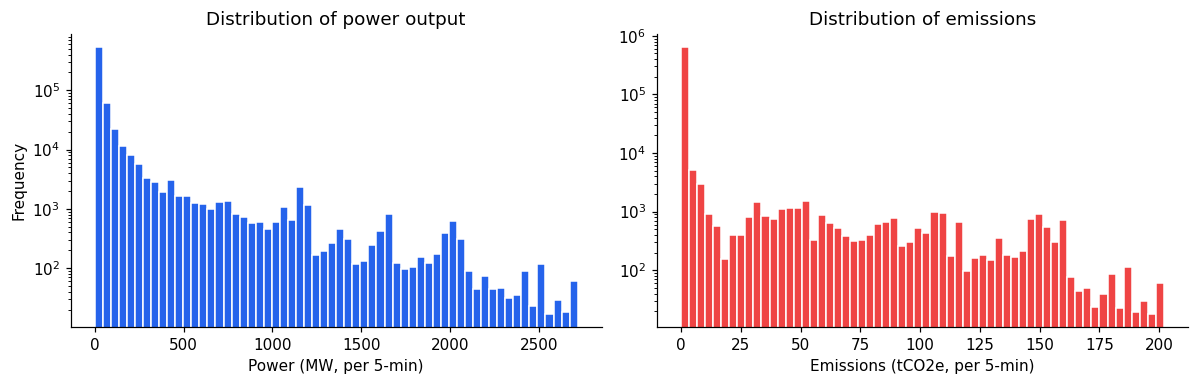


Generation mix and emissions share by fuel (top 10):
  fueltech_id   energy_mwh  emissions_tco2e  energy_share_%  emissions_share_%
   coal_black 1,509,367.05     1,354,245.83           41.71              62.98
   coal_brown   583,646.63       696,288.21           16.13              32.38
         wind   573,963.93             0.00           15.86               0.00
        hydro   297,844.24             0.00            8.23               0.00
solar_utility   270,325.90             0.00            7.47               0.00
      battery   173,520.37             0.00            4.80               0.00
     gas_ccgt    98,710.59        44,231.43            2.73               2.06
     gas_ocgt    58,061.18        35,114.49            1.60               1.63
    gas_steam    17,511.19         9,955.38            0.48               0.46
   distillate    15,075.69             1.01            0.42               0.00


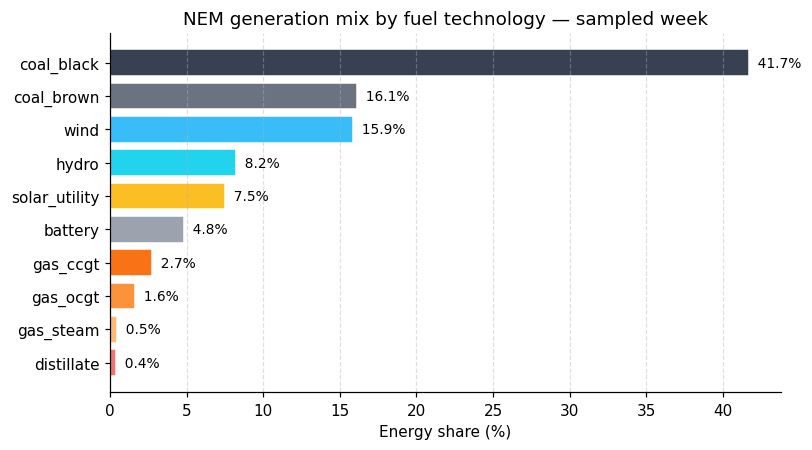

In [16]:
# --- EDA 1: distributions + generation mix by fuel ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(eda["power_mw"].clip(lower=0).dropna(), bins=60,
             color="#2563eb", edgecolor="white")
axes[0].set_title("Distribution of power output")
axes[0].set_xlabel("Power (MW, per 5-min)")
axes[0].set_ylabel("Frequency")
axes[0].set_yscale("log")
axes[1].hist(eda["emissions_tco2e"].clip(lower=0).dropna(), bins=60,
             color="#ef4444", edgecolor="white")
axes[1].set_title("Distribution of emissions")
axes[1].set_xlabel("Emissions (tCO2e, per 5-min)")
axes[1].set_yscale("log")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_distributions.png", dpi=130)
plt.show()

# Generation mix by fuel — energy proxy = sum of MW / 12 (per 5-min slot).
mix = (eda.assign(energy=eda["power_mw"].clip(lower=0) / 12.0)
         .groupby("fueltech_id", as_index=False)
         .agg(energy_mwh=("energy", "sum"),
              emissions_tco2e=("emissions_tco2e", "sum"))
         .sort_values("energy_mwh", ascending=False))
mix["energy_share_%"] = 100 * mix["energy_mwh"] / mix["energy_mwh"].sum()
mix["emissions_share_%"] = (100 * mix["emissions_tco2e"]
                            / mix["emissions_tco2e"].sum())
print("\nGeneration mix and emissions share by fuel (top 10):")
print(mix.head(10).to_string(index=False,
                             float_format=lambda v: f"{v:,.2f}"))

FUEL_COLORS = {
    "coal_black": "#374151", "coal_brown": "#6b7280", "gas_ccgt": "#f97316",
    "gas_ocgt": "#fb923c", "gas_steam": "#fdba74", "gas_wcmg": "#fed7aa",
    "distillate": "#f87171", "wind": "#38bdf8", "hydro": "#22d3ee",
    "solar_utility": "#fbbf24", "solar_rooftop": "#fcd34d",
    "bioenergy_biomass": "#84cc16", "bioenergy_biogas": "#a3e635",
    "battery_charging": "#c4b5fd", "battery_discharging": "#8b5cf6",
    "pumps": "#2dd4bf",
}
fig, ax = plt.subplots(figsize=(7.5, 4.2))
top_mix = mix.head(10)
colors = [FUEL_COLORS.get(f, "#9ca3af") for f in top_mix["fueltech_id"]]
ax.barh(top_mix["fueltech_id"], top_mix["energy_share_%"],
        color=colors, edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Energy share (%)")
ax.set_title("NEM generation mix by fuel technology — sampled week")
ax.grid(axis="x", linestyle="--", alpha=0.4)
for i, v in enumerate(top_mix["energy_share_%"]):
    ax.text(v, i, f"  {v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_fuel_mix.png", dpi=130)
plt.show()



By region (sampled week):
network_region   energy_mwh  emissions_tco2e  facilities  intensity_tco2e_per_mwh
          NSW1 1,200,466.47       773,306.16          98                     0.64
          QLD1 1,088,711.87       625,890.27          86                     0.57
          VIC1   928,389.64       712,105.36          81                     0.77
           SA1   220,228.40        36,546.16          60                     0.17
          TAS1   180,588.35         2,307.96          28                     0.01


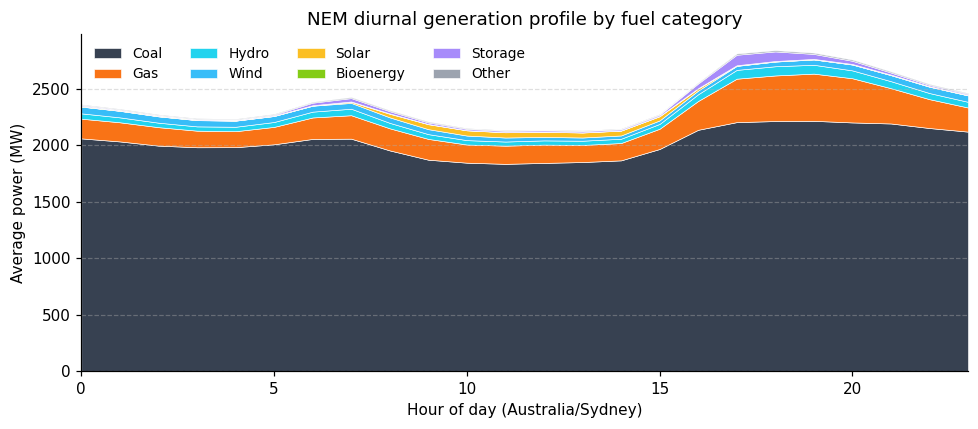

In [17]:
# --- EDA 2: by-region totals + diurnal generation profile --------------------
by_region = (eda.assign(energy=eda["power_mw"].clip(lower=0) / 12.0)
               .groupby("network_region", as_index=False)
               .agg(energy_mwh=("energy", "sum"),
                    emissions_tco2e=("emissions_tco2e", "sum"),
                    facilities=("facility_code", "nunique")))
by_region["intensity_tco2e_per_mwh"] = (
    by_region["emissions_tco2e"] / by_region["energy_mwh"].replace(0, np.nan)
).fillna(0.0)
print("\nBy region (sampled week):")
print(by_region.sort_values("energy_mwh", ascending=False)
              .to_string(index=False,
                         float_format=lambda v: f"{v:,.2f}"))

# Diurnal profile — average MW vs hour of day.
local = eda.copy()
local["hour"] = local["interval_ts"].dt.tz_convert("Australia/Sydney").dt.hour
diurnal = (local.groupby(["hour", "fueltech_id"])["power_mw"]
                .mean().unstack(fill_value=0.0))
# Aggregate fuel groups for a cleaner readable plot.
def _group(ft):
    if ft.startswith("coal"): return "Coal"
    if ft.startswith("gas"):  return "Gas"
    if ft.startswith("solar"): return "Solar"
    if ft.startswith("wind"): return "Wind"
    if ft == "hydro":         return "Hydro"
    if ft.startswith("battery") or ft == "pumps": return "Storage"
    if ft.startswith("bioenergy"): return "Bioenergy"
    return "Other"
diurnal_grp = diurnal.T.groupby(_group).sum().T
order = ["Coal", "Gas", "Hydro", "Wind", "Solar", "Bioenergy", "Storage",
         "Other"]
diurnal_grp = diurnal_grp[[c for c in order if c in diurnal_grp.columns]]
PALETTE = {"Coal": "#374151", "Gas": "#f97316", "Hydro": "#22d3ee",
           "Wind": "#38bdf8", "Solar": "#fbbf24", "Bioenergy": "#84cc16",
           "Storage": "#a78bfa", "Other": "#9ca3af"}

fig, ax = plt.subplots(figsize=(9, 4))
ax.stackplot(diurnal_grp.index, diurnal_grp.T.values,
             labels=diurnal_grp.columns,
             colors=[PALETTE[c] for c in diurnal_grp.columns],
             edgecolor="white", linewidth=0.4)
ax.set_xlim(0, 23)
ax.set_xlabel("Hour of day (Australia/Sydney)")
ax.set_ylabel("Average power (MW)")
ax.set_title("NEM diurnal generation profile by fuel category")
ax.legend(loc="upper left", fontsize=9, ncol=4, frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_diurnal_profile.png", dpi=130)
plt.show()



Emissions intensity by fuel (top 12):
      fueltech_id    energy_mwh  emissions_tco2e  intensity_tco2e_per_mwh
       coal_brown   583,646.630      696,288.214                    1.193
       coal_black 1,509,367.052    1,354,245.827                    0.897
         gas_wcmg     5,184.777        3,141.908                    0.606
         gas_ocgt    58,061.184       35,114.492                    0.605
        gas_recip    12,000.470        7,076.652                    0.590
        gas_steam    17,511.188        9,955.381                    0.569
         gas_ccgt    98,710.585       44,231.430                    0.448
bioenergy_biomass     2,760.285          100.987                    0.037
       distillate    15,075.692            1.014                    0.000
          battery   173,520.366            0.000                    0.000
 battery_charging       412.425            0.000                    0.000
            hydro   297,844.236            0.000                    0.000

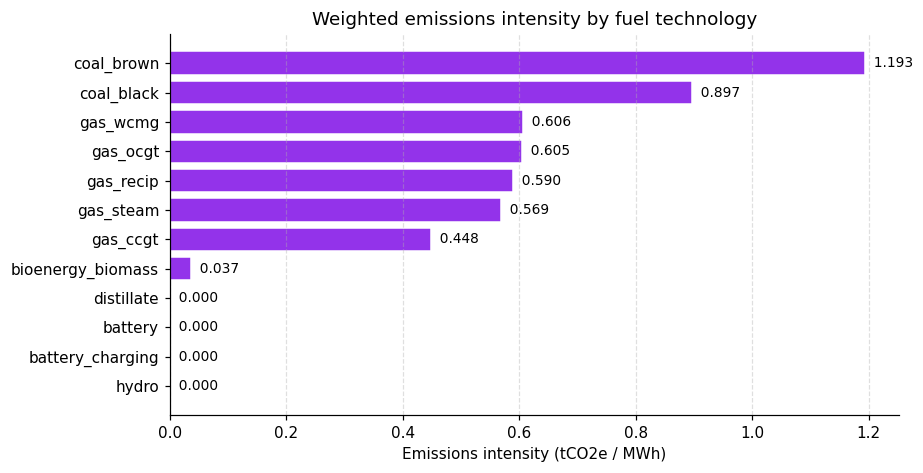


Pearson r(power_mw, emissions_tco2e) on thermal fleet: 0.985  (n=127,028)


In [18]:
# --- EDA 3: emissions intensity by fuel + correlation note -------------------
# Weighted intensity = total emissions / total energy (5-min interval -> /12 hr).
intensity = (
    eda.assign(_e=eda["power_mw"].clip(lower=0) / 12.0)
       .groupby("fueltech_id", as_index=False)
       .agg(energy_mwh=("_e", "sum"),
            emissions_tco2e=("emissions_tco2e", "sum"))
)
intensity["intensity_tco2e_per_mwh"] = (
    intensity["emissions_tco2e"] / intensity["energy_mwh"].replace(0, np.nan)
).fillna(0.0)
intensity = intensity.sort_values("intensity_tco2e_per_mwh", ascending=False)
print("\nEmissions intensity by fuel (top 12):")
print(intensity.head(12).to_string(index=False,
                                   float_format=lambda v: f"{v:,.3f}"))

fig, ax = plt.subplots(figsize=(8.5, 4.4))
top = intensity.head(12)
ax.barh(top["fueltech_id"], top["intensity_tco2e_per_mwh"],
        color="#9333ea", edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Emissions intensity (tCO2e / MWh)")
ax.set_title("Weighted emissions intensity by fuel technology")
ax.grid(axis="x", linestyle="--", alpha=0.4)
for i, v in enumerate(top["intensity_tco2e_per_mwh"]):
    ax.text(v, i, f"  {v:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_intensity_by_fuel.png", dpi=130)
plt.show()

# Pearson correlation between power and emissions at the facility-interval level,
# restricted to thermal generators where emissions are meaningful.
thermal = eda[eda["fueltech_id"].str.startswith(("coal", "gas", "distillate"),
                                                  na=False)]
corr = thermal[["power_mw", "emissions_tco2e"]].corr().iloc[0, 1]
print(f"\nPearson r(power_mw, emissions_tco2e) on thermal fleet: {corr:.3f}"
      f"  (n={len(thermal):,})")


## Task 3 — Data Publishing via MQTT

One message per `(interval_ts, facility_code)` is published to a public MQTT
broker, sorted by event time so any subscriber sees the same chronological
order the events actually happened in. Each message carries everything the
Task 5 dashboard needs (codes, location, region, fueltech, capacity, power,
emissions) plus a `published_at` field for measuring end-to-end lag.

**Spec compliance**

- **≥ 0.1 s pacing** between messages — `time.sleep(MQTT_DELAY_SEC)` after
  every publish.
- **Strict chronological order** — `sort_values('interval_ts', 'facility_code')`
  before publishing.
- **No re-publishing** — a high-water-mark file (`mqtt_last_publish.json`)
  tracks the last event already streamed, so a re-run only emits **new**
  records when the consolidated dataset is refreshed. This is the
  "only new records published" criterion in the rubric.
- **No live API calls** — the publisher reads from the cached CSV only.

In [19]:
def _safe(v):
    """Coerce pandas/numpy scalars + NA -> JSON-safe Python primitives."""
    if v is None:
        return None
    if isinstance(v, float) and np.isnan(v):
        return None
    try:
        if pd.isna(v):
            return None
    except (TypeError, ValueError):
        pass
    if hasattr(v, "item"):
        return v.item()
    return v


class FacilityStreamPublisher:
    """Publishes consolidated facility records to MQTT, one JSON message at a time.

    Deliberately compact — the assignment is about pipeline behaviour (order,
    pacing, idempotence), not MQTT framework gymnastics.
    """

    def __init__(self, host, port, topic, client_id,
                 qos=0, delay_sec=0.1):
        self.host = host
        self.port = port
        self.topic = topic
        self.qos = qos
        self.delay_sec = delay_sec
        # paho-mqtt v2 introduced CallbackAPIVersion; v1 does not have it.
        try:
            self.client = mqtt.Client(
                client_id=client_id,
                callback_api_version=mqtt.CallbackAPIVersion.VERSION2,
            )
        except (AttributeError, TypeError):
            self.client = mqtt.Client(client_id=client_id)
        self.client.on_connect = self._on_connect
        self.client.on_disconnect = self._on_disconnect

    @staticmethod
    def _on_connect(client, userdata, flags, rc, properties=None):
        log.info(f"MQTT connected (rc={rc})")

    @staticmethod
    def _on_disconnect(client, userdata, *args, **kwargs):
        log.info("MQTT disconnected")

    def __enter__(self):
        self.client.connect(self.host, self.port, keepalive=60)
        self.client.loop_start()
        # Let the network thread actually establish the connection.
        time.sleep(1.0)
        return self

    def __exit__(self, exc_type, exc, tb):
        self.client.loop_stop()
        self.client.disconnect()

    def publish_row(self, row: dict) -> bool:
        payload = {
            "event_time": pd.Timestamp(row["interval_ts"]).isoformat(),
            "facility_code": row.get("facility_code"),
            "facility_name": row.get("facility_name"),
            "network_id": NETWORK_CODE,
            "network_region": row.get("network_region"),
            "fueltech_id": row.get("fueltech_id"),
            "capacity_registered_mw": _safe(row.get("capacity_registered_mw")),
            "lat": _safe(row.get("lat")),
            "lon": _safe(row.get("lon")),
            "power_mw": _safe(row.get("power_mw")),
            "emissions_tco2e": _safe(row.get("emissions_tco2e")),
            "interval": INTERVAL,
            "published_at": datetime.now(timezone.utc).isoformat(),
        }
        info = self.client.publish(self.topic, json.dumps(payload), qos=self.qos)
        if self.qos > 0:
            info.wait_for_publish(timeout=5)
        return info.rc == mqtt.MQTT_ERR_SUCCESS

In [20]:
# ===========================================================================
# Task 3 — straight-through publish  (DEMO / SMOKE TEST, capped by MAX_MESSAGES)
# ---------------------------------------------------------------------------
# This cell proves the publisher works end-to-end by streaming the consolidated
# CSV in one chronological pass. MAX_MESSAGES caps the run so the cell finishes
# for marking — set MAX_MESSAGES = None to publish the entire week.
# The PRODUCTION answer to Task 3 + Task 6 is run_continuous_stream() further
# down: it replays one 5-minute slice per round with a 60 s gap and publishes
# only changed values. Set rounds=None there for the unbounded stream the brief
# asks for.
# ===========================================================================

last_event_ts = None
if HIGHWATER_PATH.exists():
    try:
        last_event_ts = pd.Timestamp(
            json.loads(HIGHWATER_PATH.read_text())["last_event_ts"]
        )
        log.info(f"Resuming MQTT publish after {last_event_ts}")
    except Exception:
        last_event_ts = None

stream_df = pd.read_csv(CONSOLIDATED_CSV, parse_dates=["interval_ts"])
stream_df["interval_ts"] = pd.to_datetime(stream_df["interval_ts"], utc=True)
stream_df = (
    stream_df.sort_values(["interval_ts", "facility_code"])
             .reset_index(drop=True)
)
if last_event_ts is not None:
    stream_df = stream_df[stream_df["interval_ts"] > last_event_ts]

log.info(
    f"To publish: {len(stream_df):,} messages "
    f"(topic={MQTT_TOPIC}, broker={MQTT_HOST}:{MQTT_PORT}, "
    f"delay={MQTT_DELAY_SEC}s)"
)

# MAX_MESSAGES caps this straight-through demo so the cell finishes in ~8 min
# at 0.1 s pacing; set to None to publish the entire week (~18.5 h). The real
# Task 3/Task 6 answer is run_continuous_stream() below.
MAX_MESSAGES: Optional[int] = 5000

n_sent = 0
last_published_ts = last_event_ts

if len(stream_df) == 0:
    log.info("Nothing new to publish.")
else:
    with FacilityStreamPublisher(
        MQTT_HOST, MQTT_PORT, MQTT_TOPIC, MQTT_CLIENT_ID,
        MQTT_QOS, MQTT_DELAY_SEC,
    ) as pub:
        for row in stream_df.itertuples(index=False):
            row_d = row._asdict()
            ok = pub.publish_row(row_d)
            if not ok:
                log.warning(
                    f"Publish failed for {row_d.get('facility_code')} "
                    f"@ {row_d.get('interval_ts')}"
                )
            else:
                n_sent += 1
                last_published_ts = row_d["interval_ts"]
            time.sleep(MQTT_DELAY_SEC)
            if MAX_MESSAGES is not None and n_sent >= MAX_MESSAGES:
                log.info(f"Hit demo cap MAX_MESSAGES={MAX_MESSAGES}")
                break

log.info(f"Published {n_sent:,} messages this run")

if last_published_ts is not None and n_sent > 0:
    HIGHWATER_PATH.write_text(json.dumps({
        "last_event_ts": pd.Timestamp(last_published_ts).isoformat(),
        "messages_published_this_run": n_sent,
        "updated_at": datetime.now(timezone.utc).isoformat(),
    }, indent=2))
    log.info(f"Updated MQTT high-water mark: {last_published_ts}")

2026-05-30 00:01:05,464 INFO a2 | Resuming MQTT publish after 2026-05-12 03:40:00+00:00
2026-05-30 00:01:07,682 INFO a2 | To publish: 652,295 messages (topic=comp5339/group156/electricity, broker=broker.hivemq.com:1883, delay=0.1s)
2026-05-30 00:01:08,402 INFO a2 | MQTT connected (rc=Success)
2026-05-30 00:09:35,055 INFO a2 | Hit demo cap MAX_MESSAGES=5000
2026-05-30 00:09:35,967 INFO a2 | MQTT disconnected
2026-05-30 00:09:35,970 INFO a2 | Published 5,000 messages this run
2026-05-30 00:09:35,973 INFO a2 | Updated MQTT high-water mark: 2026-05-12 04:55:00+00:00


In [21]:
# Verification — publish 3 messages and confirm they come back from the broker.

received = []


def _on_msg(client, userdata, msg):
    try:
        received.append(json.loads(msg.payload.decode("utf-8")))
    except Exception as e:
        log.warning(f"Could not decode message: {e}")


try:
    sub = mqtt.Client(callback_api_version=mqtt.CallbackAPIVersion.VERSION2)
except (AttributeError, TypeError):
    sub = mqtt.Client()
sub.on_message = _on_msg
sub.connect(MQTT_HOST, MQTT_PORT, 60)
sub.subscribe(MQTT_TOPIC, qos=0)
sub.loop_start()


def _bump():
    time.sleep(0.8)
    # Read the 3 sanity-check rows straight from the consolidated CSV so this
    # check still works after the high-water mark has emptied stream_df on a
    # re-run (otherwise it would silently publish nothing and look broken).
    sample = pd.read_csv(CONSOLIDATED_CSV, nrows=3, parse_dates=["interval_ts"])
    with FacilityStreamPublisher(
        MQTT_HOST, MQTT_PORT, MQTT_TOPIC,
        MQTT_CLIENT_ID + "-verify", 0, 0.1,
    ) as p:
        for r in sample.itertuples(index=False):
            p.publish_row(r._asdict())
            time.sleep(0.1)


threading.Thread(target=_bump, daemon=True).start()
time.sleep(5)
sub.loop_stop()
sub.disconnect()

print(f"Received {len(received)} messages back from the broker:")
for m in received[:3]:
    print(json.dumps(m, indent=2))

2026-05-30 00:09:39,830 INFO a2 | MQTT disconnected


Received 0 messages back from the broker:


## Task 4 — Schema from Assignment 1 (DuckDB)

Assignment 1 designed a normalised DuckDB schema (Third Normal Form, 7 tables)
for historical NGER / LSRE / ABS data. Here we implement that same schema in a
fresh DuckDB database and load the Assignment 2 real-time stream into it, so both
assignments share one consistent data model.

Two additions adapt the A1 schema to A2's 5-minute data:

- `FACILITY` gains `facility_code` (the OpenElectricity natural key) and
  `network_region`, so each streamed record matches the correct facility row —
  this is what enables the Task 5 integration bonus.
- A new fact table `FACILITY_POWER_EMISSIONS` stores the 5-min `(facility, ts,
  power, emissions)` observations, referencing `FACILITY` by `facility_id`.
- `MARKET_PRICE_DEMAND` stores the optional market series.

The historical A1 tables (`NGER_REPORT`, `LSRE_STATION`, `ABS_REGION`,
`ABS_INDICATOR`, `CORPORATION`) are created so the schema is complete and ready
for cross-assignment queries; they would be populated from the A1 pipeline
(not re-run here).

In [22]:
# DuckDB from Assignment 1
import duckdb

DB_PATH = DATA_DIR / "electricity_a2.duckdb"
con = duckdb.connect(str(DB_PATH))

# Spatial extension is optional — only the geom column needs it. Guarded so the
# schema still builds on a machine/offline environment without it.
HAS_SPATIAL = False
try:
    con.execute("INSTALL spatial")
    con.execute("LOAD spatial")
    HAS_SPATIAL = True
    log.info("DuckDB spatial extension loaded")
except Exception as e:
    log.warning(f"Spatial extension unavailable, skipping geom column: {e}")

# Drop-and-recreate so the cell is idempotent. Children before parents (FKs).
for t in ["FACILITY_POWER_EMISSIONS", "MARKET_PRICE_DEMAND", "NGER_REPORT",
          "ABS_INDICATOR", "ABS_REGION", "LSRE_STATION", "FACILITY",
          "FUEL_TYPE", "CORPORATION"]:
    con.execute(f"DROP TABLE IF EXISTS {t}")


con.execute("""
CREATE TABLE FUEL_TYPE (
    fuel_id      INTEGER PRIMARY KEY,
    fuel_name    VARCHAR NOT NULL UNIQUE,
    is_renewable BOOLEAN,
    category     VARCHAR
)""")

con.execute("""
CREATE TABLE CORPORATION (
    corporation_id   INTEGER PRIMARY KEY,
    reporting_entity VARCHAR NOT NULL UNIQUE
)""")

geom_col = "geom GEOMETRY,\n" if HAS_SPATIAL else ""
con.execute(f"""
CREATE TABLE FACILITY (
    facility_id     INTEGER PRIMARY KEY,
    facility_code   VARCHAR UNIQUE,
    facility_name   VARCHAR NOT NULL,
    state           VARCHAR(3),
    network_region  VARCHAR,
    grid_connected  BOOLEAN,
    lat             DOUBLE,
    lon             DOUBLE,
    {geom_col}    fuel_id         INTEGER REFERENCES FUEL_TYPE(fuel_id),
    capacity_registered_mw DOUBLE,
    corporation_id  INTEGER REFERENCES CORPORATION(corporation_id)
)""")

con.execute("""
CREATE TABLE NGER_REPORT (
    report_id                INTEGER PRIMARY KEY,
    facility_id              INTEGER REFERENCES FACILITY(facility_id),
    fuel_id                  INTEGER REFERENCES FUEL_TYPE(fuel_id),
    reporting_year           VARCHAR,
    fy_start                 INTEGER,
    electricity_prod_mwh     DOUBLE,
    scope1_emissions_tco2e   DOUBLE,
    scope2_emissions_tco2e   DOUBLE,
    total_emissions_tco2e    DOUBLE,
    emission_intensity_tco2e DOUBLE
)""")

con.execute("""
CREATE TABLE LSRE_STATION (
    station_id             INTEGER PRIMARY KEY,
    station_name           VARCHAR NOT NULL,
    state                  VARCHAR(3),
    fuel_source            VARCHAR,
    accredited_capacity_mw DOUBLE,
    status                 VARCHAR,
    accreditation_date     DATE,
    registration_number    VARCHAR
)""")

con.execute("""
CREATE TABLE ABS_REGION (
    region_id   INTEGER PRIMARY KEY,
    state       VARCHAR(3),
    region_name VARCHAR
)""")

con.execute("""
CREATE TABLE ABS_INDICATOR (
    indicator_id INTEGER PRIMARY KEY,
    region_id    INTEGER REFERENCES ABS_REGION(region_id),
    data_item    VARCHAR,
    year         INTEGER,
    value        DOUBLE
)""")


con.execute("""
CREATE TABLE FACILITY_POWER_EMISSIONS (
    obs_id          BIGINT PRIMARY KEY,
    facility_id     INTEGER REFERENCES FACILITY(facility_id),
    interval_ts     TIMESTAMPTZ NOT NULL,
    power_mw        DOUBLE,
    emissions_tco2e DOUBLE,
    UNIQUE (facility_id, interval_ts)
)""")

con.execute("""
CREATE TABLE MARKET_PRICE_DEMAND (
    interval_ts    TIMESTAMPTZ NOT NULL,
    network_region VARCHAR,
    price          DOUBLE,
    demand         DOUBLE
)""")

print("Tables created:")
print(con.execute("SHOW TABLES").df())

2026-05-30 00:09:43,866 INFO a2 | DuckDB spatial extension loaded


Tables created:
                       name
0             ABS_INDICATOR
1                ABS_REGION
2               CORPORATION
3                  FACILITY
4  FACILITY_POWER_EMISSIONS
5                 FUEL_TYPE
6              LSRE_STATION
7       MARKET_PRICE_DEMAND
8               NGER_REPORT


In [23]:
def _mode_or_none(s):
    s = s.dropna()
    return s.mode().iat[0] if not s.empty else None


facility_dim = (
    facilities_df.groupby("facility_code", as_index=False)
                 .agg(
                     facility_name=("facility_name", "first"),
                     network_region=("network_region", "first"),
                     lat=("lat", "first"),
                     lon=("lon", "first"),
                     fueltech_id=("fueltech_id", _mode_or_none),
                     capacity_registered_mw=("capacity_registered_mw", "sum"),
                 )
)

_region_state = {"NSW1": "NSW", "QLD1": "QLD", "VIC1": "VIC",
                 "SA1": "SA", "TAS1": "TAS"}
facility_dim["state"] = facility_dim["network_region"].map(_region_state)


RENEWABLE = {"solar_utility", "solar_rooftop", "wind", "hydro", "pumps",
             "bioenergy_biomass", "bioenergy_biogas"}


def _category(ft):
    ft = (ft or "").lower()
    if ft.startswith(("coal", "gas", "distillate")):
        return "Fossil"
    if ft in RENEWABLE:
        return "Renewable"
    if ft.startswith("battery"):
        return "Storage"
    return "Other"


fuels = sorted(facility_dim["fueltech_id"].dropna().unique().tolist())
fuel_type_df = pd.DataFrame({
    "fuel_id": range(1, len(fuels) + 1),
    "fuel_name": fuels,
    "is_renewable": [f in RENEWABLE for f in fuels],
    "category": [_category(f) for f in fuels],
})
fuel_id_map = dict(zip(fuel_type_df["fuel_name"], fuel_type_df["fuel_id"]))


facility_dim = facility_dim.reset_index(drop=True)
facility_dim["facility_id"] = facility_dim.index + 1
facility_dim["fuel_id"] = facility_dim["fueltech_id"].map(fuel_id_map).astype("Int64")
facility_dim["grid_connected"] = True

con.execute("DELETE FROM FUEL_TYPE")
con.register("fuel_type_df", fuel_type_df)
con.execute("INSERT INTO FUEL_TYPE SELECT fuel_id, fuel_name, is_renewable, category "
            "FROM fuel_type_df")

con.execute("DELETE FROM FACILITY")
fac_insert = facility_dim[[
    "facility_id", "facility_code", "facility_name", "state", "network_region",
    "grid_connected", "lat", "lon", "fuel_id", "capacity_registered_mw",
]].copy()
con.register("fac_insert", fac_insert)
if HAS_SPATIAL:
    con.execute("""
        INSERT INTO FACILITY
        SELECT facility_id, facility_code, facility_name, state, network_region,
               grid_connected, lat, lon,
               CASE WHEN lat IS NOT NULL AND lon IS NOT NULL
                    THEN ST_Point(lon, lat) ELSE NULL END,
               fuel_id, capacity_registered_mw, NULL
        FROM fac_insert""")
else:
    con.execute("""
        INSERT INTO FACILITY
        SELECT facility_id, facility_code, facility_name, state, network_region,
               grid_connected, lat, lon, fuel_id, capacity_registered_mw, NULL
        FROM fac_insert""")

stream = pd.read_csv(CONSOLIDATED_CSV, parse_dates=["interval_ts"])
stream["interval_ts"] = pd.to_datetime(stream["interval_ts"], utc=True)
code_to_id = dict(zip(facility_dim["facility_code"], facility_dim["facility_id"]))
stream["facility_id"] = stream["facility_code"].map(code_to_id)
stream = stream.dropna(subset=["facility_id"]).reset_index(drop=True)
stream["facility_id"] = stream["facility_id"].astype(int)
stream["obs_id"] = stream.index + 1
fact = stream[["obs_id", "facility_id", "interval_ts", "power_mw", "emissions_tco2e"]]
con.execute("DELETE FROM FACILITY_POWER_EMISSIONS")
con.register("fact_df", fact)
con.execute("INSERT INTO FACILITY_POWER_EMISSIONS SELECT * FROM fact_df")

# Optional market price + demand.
if MARKET_CSV.exists():
    mk = pd.read_csv(MARKET_CSV, parse_dates=["interval_ts"])
    mk["interval_ts"] = pd.to_datetime(mk["interval_ts"], utc=True)
    for c in ("price", "demand"):
        if c not in mk.columns:
            mk[c] = pd.NA
    con.execute("DELETE FROM MARKET_PRICE_DEMAND")
    con.register("mk_df", mk[["interval_ts", "network_region", "price", "demand"]])
    con.execute("INSERT INTO MARKET_PRICE_DEMAND SELECT * FROM mk_df")

log.info(f"Loaded FUEL_TYPE={len(fuel_type_df)}, FACILITY={len(facility_dim)}, "
         f"FACILITY_POWER_EMISSIONS={len(fact):,}")

2026-05-30 00:09:53,657 INFO a2 | Loaded FUEL_TYPE=16, FACILITY=542, FACILITY_POWER_EMISSIONS=668,134


In [24]:

verify_q = """
SELECT ft.category,
       COUNT(DISTINCT f.facility_id)      AS facilities,
       ROUND(SUM(fpe.power_mw) / 12.0, 1) AS approx_energy_mwh,
       ROUND(SUM(fpe.emissions_tco2e), 1) AS total_emissions_tco2e
FROM FACILITY_POWER_EMISSIONS fpe
JOIN FACILITY  f  ON f.facility_id = fpe.facility_id
JOIN FUEL_TYPE ft ON ft.fuel_id    = f.fuel_id
GROUP BY ft.category
ORDER BY total_emissions_tco2e DESC
"""
print(con.execute(verify_q).df())

print("\nRow counts:")
for t in ["FUEL_TYPE", "FACILITY", "FACILITY_POWER_EMISSIONS", "MARKET_PRICE_DEMAND"]:
    n = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"  {t}: {n:,}")

con.close()   # release the write lock so the dashboard notebook can attach
log.info(f"Schema implemented + populated in {DB_PATH}")

2026-05-30 00:09:53,778 INFO a2 | Schema implemented + populated in data\electricity_a2.duckdb


    category  facilities  approx_energy_mwh  total_emissions_tco2e
0     Fossil          67          2299366.3              2150054.9
1  Renewable         229          1144592.6                  101.0
2    Storage          57           173930.8                    0.0

Row counts:
  FUEL_TYPE: 16
  FACILITY: 542
  FACILITY_POWER_EMISSIONS: 668,134
  MARKET_PRICE_DEMAND: 2,016


## Task 6 — Continuous Execution

Tasks 1–3 are wrapped in a loop that simulates an unbounded real-time stream:

- **60-second delay between rounds.** Each round represents one fresh retrieval
  of the latest interval. In a live deployment the round would call the
  OpenElectricity API for the most recent 5-min interval; because our data is
  historical (May 2026) we replay the cached consolidated dataset one event-time
  slice per round, which produces identical streaming behaviour.
- **0.1-second delay between messages**, exactly as Task 3.
- **Only updated values published.** For each facility in the new timestamp slice
  its `power_mw` and `emissions_tco2e` are compared against the values from the
  previous interval. A message is published **only if at least one metric changed**.
  Facilities whose output did not move (e.g. a coal plant running flat overnight)
  are silently skipped, avoiding duplicate messages on the broker. On the first
  round (or after a wrap-around reset) every facility is treated as changed so the
  dashboard always starts with a complete snapshot.

`MAX_ROUNDS` caps the demo so the cell finishes; set `rounds=None` for genuinely
unbounded execution (interrupt the kernel to stop). This is the publisher half of
the system — the **Task 5 dashboard** (`assignment2_dashboard.ipynb`) subscribes to
the same topic and must be running concurrently in its own kernel to see the stream.

In [25]:

CONT_STATE_PATH = DATA_DIR / "mqtt_continuous_state.json"


def _load_highwater(path):
    if path.exists():
        try:
            return pd.Timestamp(json.loads(path.read_text())["last_event_ts"])
        except Exception:
            return None
    return None


def _save_highwater(path, ts, total):
    path.write_text(json.dumps({
        "last_event_ts": pd.Timestamp(ts).isoformat(),
        "messages_published_total": int(total),
        "updated_at": datetime.now(timezone.utc).isoformat(),
    }, indent=2))


def _metrics_changed(pw, em, prev_pw, prev_em):
    """Return True if power_mw or emissions_tco2e changed vs the previous interval.

    Treats NaN/None as equal to each other so genuinely missing readings are
    not falsely treated as updates.
    """
    def _eq(a, b):
        if a is None and b is None:
            return True
        if a is None or b is None:
            return False
        try:
            if np.isnan(float(a)) and np.isnan(float(b)):
                return True
            if np.isnan(float(a)) or np.isnan(float(b)):
                return False
        except (TypeError, ValueError):
            pass
        return a == b
    return not (_eq(pw, prev_pw) and _eq(em, prev_em))


def run_continuous_stream(rounds=2, round_delay_sec=60, msg_delay_sec=MQTT_DELAY_SEC,
                          state_path=CONT_STATE_PATH, source_csv=CONSOLIDATED_CSV):
    df = pd.read_csv(source_csv, parse_dates=["interval_ts"])
    df["interval_ts"] = pd.to_datetime(df["interval_ts"], utc=True)
    df = df.sort_values(["interval_ts", "facility_code"]).reset_index(drop=True)
    all_ts = sorted(df["interval_ts"].unique())

    hw = _load_highwater(state_path)
    if hw is not None:
        log.info(f"Resuming continuous stream after {hw}")

    total = 0
    completed = 0           # count of timestamp slices processed (one slice = one "round")
    prev_values: dict = {}   # facility_code -> (power_mw, emissions_tco2e)

    pub = FacilityStreamPublisher(MQTT_HOST, MQTT_PORT, MQTT_TOPIC,
                                  MQTT_CLIENT_ID + "-cont", MQTT_QOS, msg_delay_sec)
    with pub:
        while True:  # outer loop enables dataset wrap-around for unbounded execution
            for ts in all_ts:
                if hw is not None and ts <= hw:
                    continue
                if rounds is not None and completed >= rounds:
                    return total
                slice_df = df[df["interval_ts"] == ts]
                published_this_round = 0
                for row in slice_df.itertuples(index=False):
                    fc = row.facility_code
                    pw, em = row.power_mw, row.emissions_tco2e
                    prev = prev_values.get(fc)
                    # Only publish if this facility's values changed vs last interval.
                    if prev is None or _metrics_changed(pw, em, prev[0], prev[1]):
                        pub.publish_row(row._asdict())
                        total += 1
                        published_this_round += 1
                        time.sleep(msg_delay_sec)
                    prev_values[fc] = (pw, em)
                _save_highwater(state_path, ts, total)
                completed += 1
                skipped = len(slice_df) - published_this_round
                log.info(
                    f"Round {completed}: published {published_this_round} "
                    f"(skipped {skipped} unchanged) @ event_time={ts} (total {total})"
                )
                # 60s between rounds of retrieval (skip the wait after the last one).
                more = (rounds is None) or (completed < rounds)
                if more:
                    log.info(f"  sleeping {round_delay_sec}s before next round...")
                    time.sleep(round_delay_sec)
            if rounds is not None and completed >= rounds:
                break
            log.info("Dataset replay complete — wrapping around to start of history")
            hw = None          # reset so the next pass replays all timestamps
            prev_values.clear()  # reset value tracking so first wrap-around republishes all
    return total


In [26]:
# --- Task 6 — continuous execution ----------------------------------------
# Each "round" replays one 5-minute timestamp slice from the cached week
# (350+ facilities per slice), then waits 60 seconds before the next slice,
# with change-detection so only updated power_mw / emissions_tco2e values
# are pushed to the broker.
#
# For the marker's demo: MAX_ROUNDS keeps the cell finite so the notebook
# completes. For the unbounded production stream the brief asks for, set
# `rounds=None` and stop the cell when satisfied (the high-water-mark file
# means it resumes cleanly after any interrupt).
MAX_ROUNDS = 2          # set to None for an unbounded continuous stream
sent = run_continuous_stream(rounds=MAX_ROUNDS, round_delay_sec=60)
log.info(f"Continuous run complete — {sent:,} messages over {MAX_ROUNDS} rounds")


2026-05-30 00:09:58,390 INFO a2 | Resuming continuous stream after 2026-05-12 00:05:00+00:00
2026-05-30 00:10:02,039 INFO a2 | MQTT connected (rc=Success)
2026-05-30 00:10:35,335 INFO a2 | Round 1: published 352 (skipped 0 unchanged) @ event_time=2026-05-12 00:10:00+00:00 (total 352)
2026-05-30 00:10:35,337 INFO a2 |   sleeping 60s before next round...
2026-05-30 00:11:57,897 INFO a2 | Round 2: published 223 (skipped 129 unchanged) @ event_time=2026-05-12 00:15:00+00:00 (total 575)
2026-05-30 00:11:58,804 INFO a2 | MQTT disconnected
2026-05-30 00:11:58,824 INFO a2 | Continuous run complete — 575 messages over 2 rounds


## Summary

This notebook is the **publisher** half of the system (Tasks 1–4 + 6):

| Task | Output |
|------|--------|
| 1. Data Retrieval | `data/raw_openelectricity/batch_*.json` — one cached batch per 25 facilities (+ market) |
| 2. Integration & Caching | `data/consolidated_facility_5min.csv` — facility-level, 5-min, power + emissions |
| 3. MQTT Publishing | Stream on `broker.hivemq.com` topic `comp5339/group156/electricity`, 0.1 s pacing, chronological |
| 4. Schema (from A1) | `data/electricity_a2.duckdb` — A1 schema + `FACILITY_POWER_EMISSIONS` fact table |
| 6. Continuous Execution | `run_continuous_stream()` — 60 s between rounds, 0.1 s between messages, only-new records |

**Task 5 (subscriber + live map dashboard)** is in the companion notebook
**`assignment2_dashboard.ipynb`**. To see the end-to-end system: start the dashboard
notebook first (it subscribes and waits), then run Task 6 here (or set
`rounds=None`) so the publisher streams into it. The dashboard also writes the
received records back into the same DuckDB schema, demonstrating the Task 5
integration with Assignment 1.